Cell 1 — Import & Load Data

In [41]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score

df = pd.read_csv(r'e:\coding\TUGAS AKHIR\data\gempa_1990-2026.csv')
df['time'] = pd.to_datetime(df['time'])
df['bulan'] = df['time'].dt.month
df['jam'] = df['time'].dt.hour


Cell 2 — Buat Label

In [42]:
def buat_label(mag):
    return 0 if mag < 5.0 else 1

df['label'] = df['mag'].apply(buat_label)


Cell 3 — Pendekatan 1: Drop Kolom

In [43]:
from sklearn.model_selection import RandomizedSearchCV

fitur_1 = ['latitude', 'longitude', 'depth', 'bulan', 'jam']
df1 = df[fitur_1 + ['label']].dropna().reset_index(drop=True)
X1, y1 = df1[fitur_1], df1['label']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

scale1 = (y1_train == 0).sum() / (y1_train == 1).sum() * 10

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

base1 = XGBClassifier(scale_pos_weight=scale1, eval_metric='logloss', random_state=42)
search1 = RandomizedSearchCV(base1, param_grid, n_iter=30, scoring='f1', cv=5,
                              random_state=42, n_jobs=-1, verbose=1)
search1.fit(X1_train, y1_train)

print("Best params (Drop Kolom):", search1.best_params_)
print("Best F1 CV:", round(search1.best_score_, 4))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (Drop Kolom): {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best F1 CV: 0.277


Cell 4 — Pendekatan 2: Imputasi Median

In [44]:
fitur_2 = ['latitude', 'longitude', 'depth', 'gap', 'dmin', 'nst', 'bulan', 'jam']
df2 = df[fitur_2 + ['label']].copy()
for col in ['gap', 'dmin', 'nst']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')
    df2[col] = df2[col].fillna(df2[col].median())
df2 = df2.dropna().reset_index(drop=True)

X2, y2 = df2[fitur_2], df2['label']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

scale2 = (y2_train == 0).sum() / (y2_train == 1).sum() * 10

base2 = XGBClassifier(scale_pos_weight=scale2, eval_metric='logloss', random_state=42)
search2 = RandomizedSearchCV(base2, param_grid, n_iter=30, scoring='f1', cv=5,
                              random_state=42, n_jobs=-1, verbose=1)
search2.fit(X2_train, y2_train)

print("Best params (Imputasi Median):", search2.best_params_)
print("Best F1 CV:", round(search2.best_score_, 4))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (Imputasi Median): {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best F1 CV: 0.5565


In [45]:
print("Jumlah High-mag di train:", (y1_train == 1).sum())
print("Jumlah Low-mag di train:", (y1_train == 0).sum())
print("Jumlah High-mag di test:", (y1_test == 1).sum())
print("Jumlah Low-mag di test:", (y1_test == 0).sum())


Jumlah High-mag di train: 6815
Jumlah Low-mag di train: 43916
Jumlah High-mag di test: 1704
Jumlah Low-mag di test: 10979


tarining final dengan early stopping

In [46]:
# ── Pendekatan 1: Drop Kolom ──
m1 = XGBClassifier(**best_params, scale_pos_weight=scale1,
                   eval_metric='aucpr', early_stopping_rounds=20, random_state=42)
m1.fit(X1_train, y1_train,
       eval_set=[(X1_train, y1_train), (X1_test, y1_test)],
       verbose=False)

# ── Pendekatan 2: Imputasi Median ──
m2 = XGBClassifier(**best_params, scale_pos_weight=scale2,
                   eval_metric='aucpr', early_stopping_rounds=20, random_state=42)
m2.fit(X2_train, y2_train,
       eval_set=[(X2_train, y2_train), (X2_test, y2_test)],
       verbose=False)

print("Training selesai")
print(f"Pendekatan 1 - best iteration: {m1.best_iteration}")
print(f"Pendekatan 2 - best iteration: {m2.best_iteration}")


Training selesai
Pendekatan 1 - best iteration: 11
Pendekatan 2 - best iteration: 38


evaluasi lengkap dan perbandingan

In [47]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

def evaluasi(nama, model, X_train, y_train, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred_train = model.predict(X_train)

    return {
        'Nama'             : nama,
        'Accuracy (train)' : round(accuracy_score(y_train, y_pred_train), 4),
        'Accuracy (test)'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision'        : round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Recall High-mag'  : round(recall_score(y_test, y_pred, pos_label=1), 4),
        'F1 High-mag'      : round(f1_score(y_test, y_pred, pos_label=1), 4),
        'AUC-ROC'          : round(roc_auc_score(y_test, y_proba), 4),
    }, y_pred

hasil1, y1_pred = evaluasi('Drop Kolom',      m1, X1_train, y1_train, X1_test, y1_test)
hasil2, y2_pred = evaluasi('Imputasi Median', m2, X2_train, y2_train, X2_test, y2_test)

# Tabel perbandingan
df_hasil = pd.DataFrame([hasil1, hasil2]).set_index('Nama')
print(df_hasil.to_string())


                 Accuracy (train)  Accuracy (test)  Precision  Recall High-mag  F1 High-mag  AUC-ROC
Nama                                                                                                
Drop Kolom                 0.1870           0.1798     0.1382           0.9754       0.2422   0.6541
Imputasi Median            0.6938           0.6823     0.2924           0.9607       0.4483   0.9190


Confusion matrix keduanya

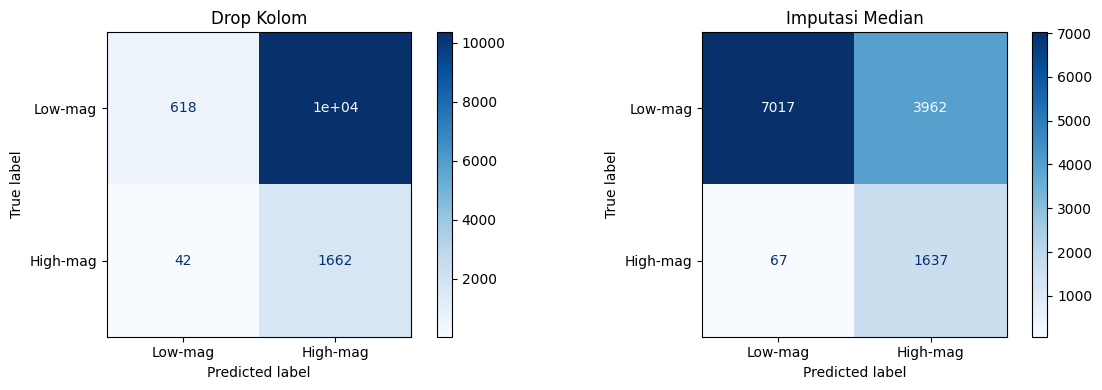

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, y_test, nama in zip(
    axes,
    [y1_pred, y2_pred],
    [y1_test, y2_test],
    ['Drop Kolom', 'Imputasi Median']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Low-mag', 'High-mag']).plot(ax=ax, cmap='Blues')
    ax.set_title(nama)

plt.tight_layout()
plt.show()


shap analysis

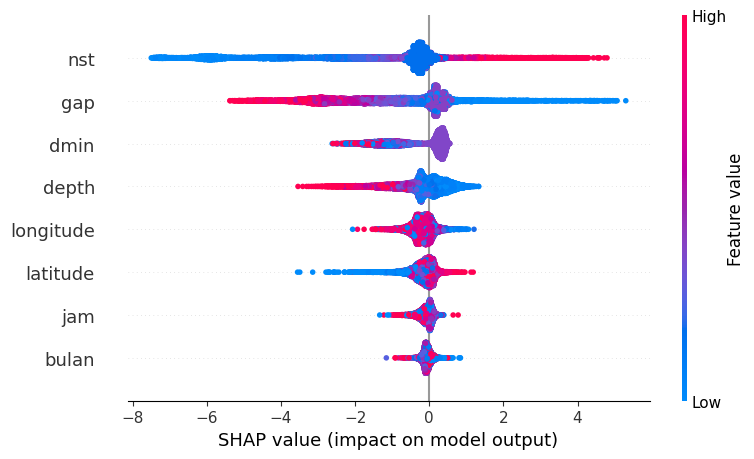

In [49]:
import shap

# Gunakan model Imputasi Median (pemenang perbandingan)
explainer = shap.TreeExplainer(m2)
shap_values = explainer.shap_values(X2_test)

# 1. Summary Plot — kontribusi semua fitur
shap.summary_plot(shap_values, X2_test, feature_names=fitur_2)


shap bar plot

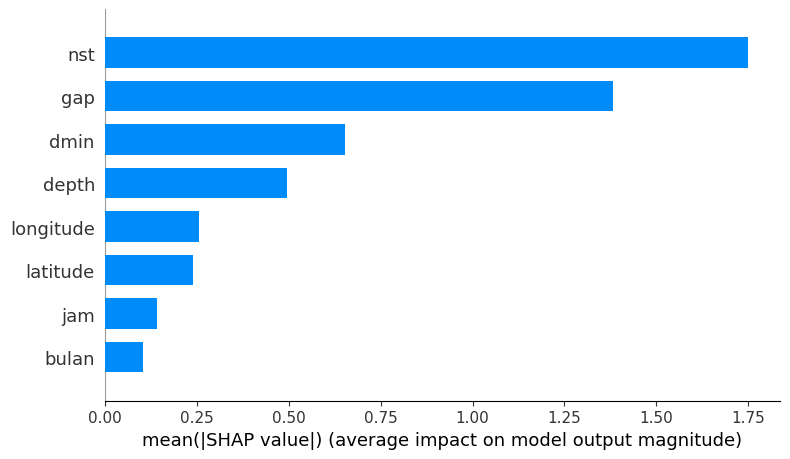

In [50]:
shap.summary_plot(shap_values, X2_test, feature_names=fitur_2, plot_type='bar')


shap dependence plot

Fitur paling penting: nst


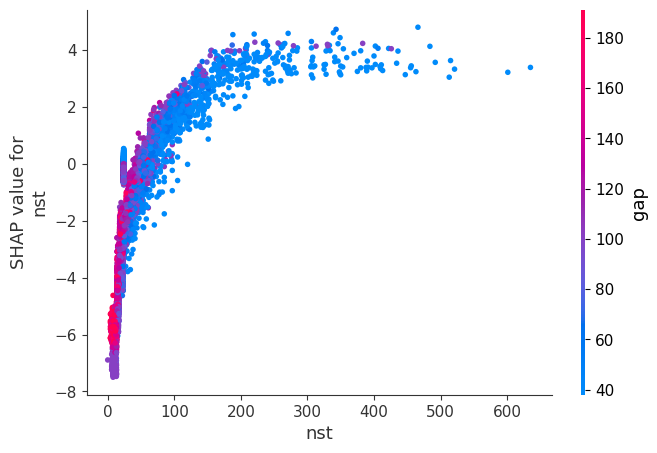

In [51]:
# Cek fitur mana yang paling penting dulu
import numpy as np
mean_shap = np.abs(shap_values).mean(axis=0)
top_fitur = fitur_2[np.argmax(mean_shap)]
print("Fitur paling penting:", top_fitur)

shap.dependence_plot(top_fitur, shap_values, X2_test, feature_names=fitur_2)


Cell 5 — Tabel Perbandingan

In [52]:
hasil = {
    'Drop Kolom': {
        'Accuracy'        : round(accuracy_score(y1_test, y1_pred), 4),
        'Recall High-mag' : round(recall_score(y1_test, y1_pred, pos_label=1), 4),
        'F1 High-mag'     : round(f1_score(y1_test, y1_pred, pos_label=1), 4),
    },
    'Imputasi Median': {
        'Accuracy'        : round(accuracy_score(y2_test, y2_pred), 4),
        'Recall High-mag' : round(recall_score(y2_test, y2_pred, pos_label=1), 4),
        'F1 High-mag'     : round(f1_score(y2_test, y2_pred, pos_label=1), 4),
    }
}

print(pd.DataFrame(hasil).T.to_string())


                 Accuracy  Recall High-mag  F1 High-mag
Drop Kolom         0.1798           0.9754       0.2422
Imputasi Median    0.6823           0.9607       0.4483
